# Solutions of Explorations of Basics-02 notebook

# __________________________________________________________________

In [1]:
import torch
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

# for reproducibility
torch.manual_seed(42)
np.random.seed(42)


# Load the dataset
# Generate data mimiking a real-world scenario
X, y = make_classification(n_samples=1000,
                            n_features=20,
                            n_informative=15,
                            n_redundant=3,
                            n_classes=2,
                            random_state=42
                            )

# Convert to tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(X, dtype = torch.float32).to(device)
y_tensor = torch.tensor(y, dtype = torch.float32, device=device)

# Initial shapes

print(f"Initial X shape : {X_tensor.shape}")
print(f"Initial y shape : {y_tensor.shape}")

# ---Indexing and slicing (Data Exploration)---

print("\n Indexing and slicing")

# Get the first engine test (first row)
first_sample = X_tensor[0]
print(f"first_sample's 20 features : {first_sample.shape}")

# Get the reading from the 5th sensor (for all 1000 tests) (5th column)

fifth_feature = X_tensor[:,4]
print(f"fifth_feature's 1000 readings : {fifth_feature.shape}")


# Get a batch of 10 samples for training

first_batch = X_tensor[:10]
print(f"First batch shape : {first_batch.shape}")

###############################

# ---Mathematical operations---

###############################

print("\nMathematical Operations")

# What is the average reading from the 5th sensor or 5th column

mean_val_5_S = torch.mean(fifth_feature)
print(f" The average value from the readings of 5th sensor is : {mean_val_5_S:.4f} ")


# Let's manually compute the output of ONE neuron

# Let's assume that our neuron is connected to the first 5 features fof the first sample
# Reminder of the equation  : z = w^T * x + b

w = torch.tensor([0.1, -0.2, 0.3, -0.4, 0.5], device=device) # Random weights
b = torch.tensor(0.1, device=device)                         # Bias term
x_neuron_input = X_tensor[0, :5]                             # First 5 reading from the sample


# The dot product
z = torch.matmul(w, x_neuron_input) + b
print(f"Input of the neuron is  : {x_neuron_input}")
print(f"\nThe output of the neuron before activation function is : {z}")


# Let's apply a non-linear activation function (ReLU) or (tanh)

a = torch.tanh(z)
print(f"Neuron's post activation output is : {a:.4f}")




# ---Reshaping Tensors (Preparing for CNNs)---
print("\nReshaping Tensors")

# Let's assume that our 20 features are actually a 4x5 grid of sensors

sample_as_grid = X_tensor[0].view(4,5) # 4 rows and 5 columns

# NOTE : The total number of elements must remain the same (4 * 5 = 20)

print(f"Original shape : {X_tensor[0].shape} -----> Reshaped : {sample_as_grid.shape}")
print(f"Sample as 4x5 grid :\n {sample_as_grid}")

Initial X shape : torch.Size([1000, 20])
Initial y shape : torch.Size([1000])

 Indexing and slicing
first_sample's 20 features : torch.Size([20])
fifth_feature's 1000 readings : torch.Size([1000])
First batch shape : torch.Size([10, 20])

Mathematical Operations
 The average value from the readings of 5th sensor is : 0.4582 
Input of the neuron is  : tensor([ 5.2181, -3.7371, -1.6401,  1.9905, -3.3040], device='cuda:0')

The output of the neuron before activation function is : -1.5710234642028809
Neuron's post activation output is : -0.9172

Reshaping Tensors
Original shape : torch.Size([20]) -----> Reshaped : torch.Size([4, 5])
Sample as 4x5 grid :
 tensor([[  5.2181,  -3.7371,  -1.6401,   1.9905,  -3.3040],
        [  0.7336,  -1.4305,  -1.3784, -13.2693,   0.9426],
        [ -2.7296,   3.6073,  -0.3429,  -2.8305,   0.5781],
        [  0.6487,   2.1284,  -1.4446,   4.8681,  -0.7088]], device='cuda:0')


# _________________________________________________________________

# ABOVE CODE IS THE ORIGINAL CODE FROM BASIC 2 NOTEBOOK

# _________________________________________________________________

In [5]:
# Select all samples that belong to class 1
class_1_samples = X_tensor[y_tensor == 1]
class_0_samples = X_tensor[y_tensor == 0]
print(f"Number of total classes to predict in dataset : {y_tensor.shape[0]}")
print(f"Number of samples in class '1' : {class_1_samples.shape[0]}")
print(f"Number of samples that have '0' label : {class_0_samples.shape[0]}")

Number of total classes to predict in dataset : 1000
Number of samples in class '1' : 501
Number of samples that have '0' label : 499


In [17]:
# Normalize the entire X_tensor by subtracting the mean and dividing by std
# This is a very important step in data preprocessing
# This is called z-score normalization
mean = torch.mean(X_tensor, 0)
std = torch.std(X_tensor, 0)
X_tensor_scaled = (X_tensor - mean) / std
X_tensor_scaled = X_tensor_scaled.clamp(-3, 3)  # Clip values to avoid outliers

In [24]:
# covariance matrix for the first five elements
# THe formula is : C = (1/(n-1)) * (X - mean(X))^T * (X - mean(X))

C = (1/(X_tensor.shape[0] - 1)) * (X_tensor[:, :5] - mean[:5]).T @ (X_tensor[:, :5] - mean[:5])
C

tensor([[ 6.3917, -0.1370, -0.0267,  0.3396,  1.0003],
        [-0.1370,  5.1751,  0.0205,  0.6935, -1.1780],
        [-0.0267,  0.0205,  1.0304, -0.0278, -0.0068],
        [ 0.3396,  0.6935, -0.0278,  4.4982,  0.2001],
        [ 1.0003, -1.1780, -0.0068,  0.2001,  4.9994]], device='cuda:0')

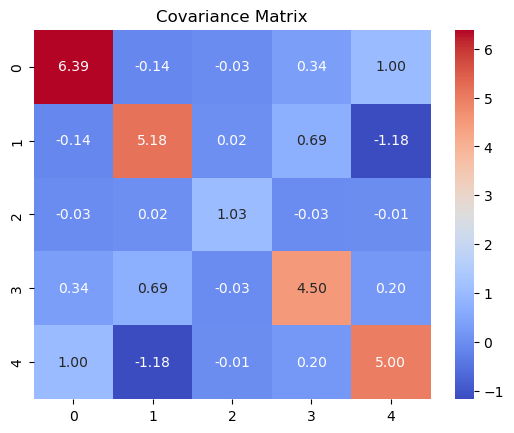

In [25]:
import seaborn as sns
C = C.cpu().numpy()

sns.heatmap(C, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Covariance Matrix")
plt.show()


# Dataset-Specific Excercises

# Replication

In [72]:
#1
from sklearn.datasets import fetch_california_housing

X,y = fetch_california_housing(return_X_y=True, as_frame=True)
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [73]:
import pandas as pd
df = pd.DataFrame(columns=('MedInc','HouseAge'),
                  data=X[['MedInc','HouseAge']])
df.head(3)

,MedInc,HouseAge
0,8.3252,41.0
1,8.3014,21.0
2,7.2574,52.0


In [74]:
df_nump = df.to_numpy()

In [75]:
df_Tensor = torch.tensor(df_nump, dtype=torch.float32, device=device)
df_Tensor.shape

torch.Size([20640, 2])

In [79]:
df

,MedInc,HouseAge
0,8.3252,41.0
1,8.3014,21.0
2,7.2574,52.0
3,5.6431,52.0
4,3.8462,52.0
...,...,...
20635,1.5603,25.0
20636,2.5568,18.0
20637,1.7000,17.0
20638,1.8672,18.0


In [78]:
df_nump

array([[ 8.3252, 41.    ],
       [ 8.3014, 21.    ],
       [ 7.2574, 52.    ],
       ...,
       [ 1.7   , 17.    ],
       [ 1.8672, 18.    ],
       [ 2.3886, 16.    ]])

In [80]:
df_Tensor[:, :1] # This is the MEdinc feature

tensor([[8.3252],
        [8.3014],
        [7.2574],
        ...,
        [1.7000],
        [1.8672],
        [2.3886]], device='cuda:0')

In [83]:
# Mean and Std of MEdinc feature

torch.mean(df_Tensor[:, :1]), torch.std(df_Tensor[:, :1])

(tensor(3.8707, device='cuda:0'), tensor(1.8998, device='cuda:0'))

# Modification

In [101]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

df = pd.DataFrame(X[:,:])
df['target'] = y

df

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [104]:
X_tensor_100 = torch.tensor(X[:100, :], dtype=torch.float32, device = device)
y_tensor_100 = torch.tensor(y[:100], dtype=torch.float32, device = device)

X_tensor_100.shape, y_tensor_100.shape


(torch.Size([100, 64]), torch.Size([100]))

In [106]:
# REshaping

X_tensor_100.reshape([100,1,8,8])

tensor([[[[ 0.,  0.,  5.,  ...,  1.,  0.,  0.],
          [ 0.,  0., 13.,  ..., 15.,  5.,  0.],
          [ 0.,  3., 15.,  ..., 11.,  8.,  0.],
          ...,
          [ 0.,  4., 11.,  ..., 12.,  7.,  0.],
          [ 0.,  2., 14.,  ..., 12.,  0.,  0.],
          [ 0.,  0.,  6.,  ...,  0.,  0.,  0.]]],


        [[[ 0.,  0.,  0.,  ...,  5.,  0.,  0.],
          [ 0.,  0.,  0.,  ...,  9.,  0.,  0.],
          [ 0.,  0.,  3.,  ...,  6.,  0.,  0.],
          ...,
          [ 0.,  0.,  1.,  ...,  6.,  0.,  0.],
          [ 0.,  0.,  1.,  ...,  6.,  0.,  0.],
          [ 0.,  0.,  0.,  ..., 10.,  0.,  0.]]],


        [[[ 0.,  0.,  0.,  ..., 12.,  0.,  0.],
          [ 0.,  0.,  3.,  ..., 14.,  0.,  0.],
          [ 0.,  0.,  8.,  ..., 16.,  0.,  0.],
          ...,
          [ 0.,  9., 16.,  ...,  0.,  0.,  0.],
          [ 0.,  3., 13.,  ..., 11.,  5.,  0.],
          [ 0.,  0.,  0.,  ..., 16.,  9.,  0.]]],


        ...,


        [[[ 0.,  0.,  0.,  ...,  1.,  0.,  0.],
          [ 0., 

# Creation

In [108]:
# Creating ytwo random tensors
tensor_A = torch.randn(3,4)
tensor_B = torch.randn(4,5)

(tensor_A @ tensor_B).shape

torch.Size([3, 5])

# Additional Beautiful plots made by AI to boost your motivation

### `BELOW`

Epoch [50/200], Loss: 0.1768, Train Acc: 0.9237
Epoch [100/200], Loss: 0.0112, Train Acc: 1.0000
Epoch [150/200], Loss: 0.0029, Train Acc: 1.0000
Epoch [200/200], Loss: 0.0016, Train Acc: 1.0000


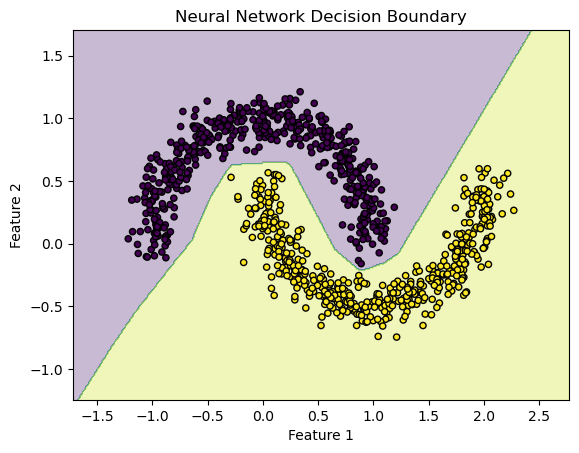

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# ========================
# 1. Prepare dataset
# ========================
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# ========================
# 2. Define ANN
# ========================
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)   # output layer (2 classes)
        )
    def forward(self, x):
        return self.layers(x)

model = ANN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ========================
# 3. Training loop
# ========================
epochs = 200
for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_train_tensor).float().mean()
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Train Acc: {acc:.4f}")

# ========================
# 4. Plot decision boundary
# ========================
def plot_decision_boundary(model, X, y):
    h = 0.01
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        Z = model(grid)
        Z = torch.argmax(Z, axis=1).numpy()
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, cmap="viridis", alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", s=20, edgecolor="k")
    plt.title("Neural Network Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(model, X, y)


Epoch [50/200], Loss: 0.0000, Train Acc: 1.0000
Epoch [100/200], Loss: 0.0000, Train Acc: 1.0000
Epoch [150/200], Loss: 0.0000, Train Acc: 1.0000
Epoch [200/200], Loss: 0.0000, Train Acc: 1.0000


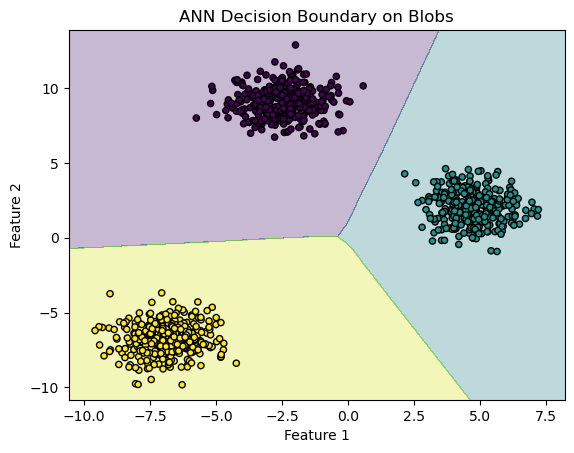

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# ========================
# 1. Generate dataset
# ========================
X, y = make_blobs(n_samples=1000, centers=3, n_features=2, cluster_std=1.0, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# ========================
# 2. Define ANN
# ========================
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 3)  # 3 classes
        )
    def forward(self, x):
        return self.layers(x)

model = ANN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ========================
# 3. Training loop
# ========================
epochs = 200
for epoch in range(epochs):
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_train_tensor).float().mean()
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Train Acc: {acc:.4f}")

# ========================
# 4. Plot decision boundary
# ========================
def plot_decision_boundary(model, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        Z = model(grid)
        Z = torch.argmax(Z, axis=1).numpy()
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap="viridis", alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", s=20, edgecolor="k")
    plt.title("ANN Decision Boundary on Blobs")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(model, X, y)
